# Luminosity Schechter

In [1]:
import numpy as np
import dask.array as da
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
import healpy as hp
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad

from iminuit import Minuit
from iminuit.cost import LeastSquares

from simulMap import *
from mappers import DepthMapper

# Set random seed for reproducibility
#np.random.seed(42)

In [2]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

Number of pixels = 49152


## Luminosity sampling

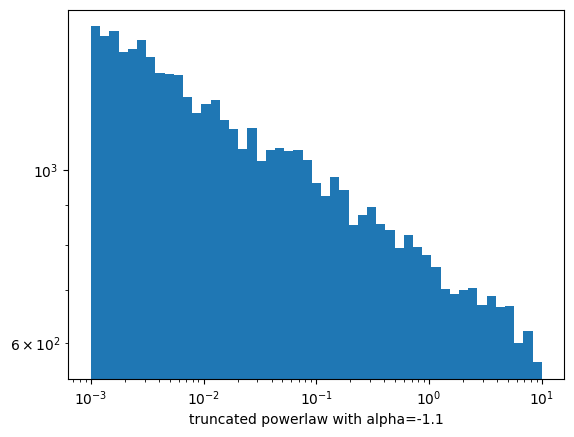

In [3]:
def sample_truncated_power_law(alpha, xmin, xmax, size=None):
    """
    Sample from a truncated power-law distribution p(x) ∝ x^alpha
    for xmin <= x <= xmax, with alpha < -1.

    Parameters:
        alpha (float): exponent (must be < -1)
        xmin (float): lower bound (> 0)
        xmax (float): upper bound (> xmin)
        size (int): number of samples

    Returns:
        numpy array of samples
    """
    if alpha == -1:
        raise ValueError("alpha = -1 requires a different (logarithmic) treatment")

    # Generate uniform random numbers
    u = np.random.uniform(0, 1, size)

    # Inverse CDF
    exponent = alpha + 1
    xmin_exp = xmin ** exponent
    xmax_exp = xmax ** exponent

    samples = (u * (xmax_exp - xmin_exp) + xmin_exp) ** (1 / exponent)

    return samples


x = sample_truncated_power_law(-1.1, 1e-3, 10, npix)
bins = np.logspace(np.log10(np.min(x)), np.log10(np.max(x)), 50)
get_hist(x, xlabel='truncated powerlaw with alpha=-1.1', bins=bins);
plt.yscale('log');
plt.xscale('log');

#### Schechter ratio:

Number of rejects = 14557


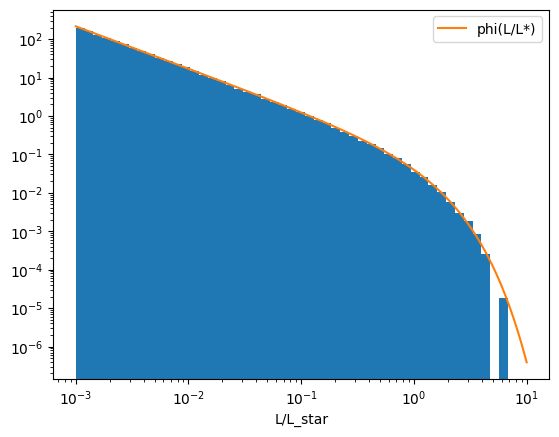

In [4]:
def proba_schechter_lumRatio(x, alpha, phi_star=1):
        return phi_star * np.power(x, alpha) * np.exp(-x)


def generate_schechter_lumRatio(N, alpha, x_min, x_max, phi_star=1, get_proba=False):
    """Generate N randomized luminosities, by using a reject test and Schechter's law."""
    samples = []
    reject = 0
    
    while len(samples) < N:
        L_cand = sample_truncated_power_law(alpha, x_min, x_max)
        
        # Acceptance ratio:
        # f(x) = x^alpha * exp(-x)
        # g(x) = x^alpha (on ignore la constante de normalisation qui s'annule)
        # f(x)/g(x) = exp(-x)
        acceptance_ratio = np.exp(-L_cand)
        
        # Acceptance test:
        u = np.random.uniform(0, 1)
        if u < acceptance_ratio:
            samples.append(L_cand)
        else:
            reject += 1
    print('Number of rejects =', reject)
    if get_proba: return np.array(samples), np.array(proba)
    else: return np.array(samples)


L_ratio = generate_schechter_lumRatio(npix, -1.1, 1e-3, 10)
bins = np.logspace(np.log10(np.min(L_ratio)), np.log10(np.max(L_ratio)), 50)
get_hist(L_ratio, xlabel='L/L_star', bins=bins, log=True, density=True)
plt.xscale('log');


L_test = np.logspace(-3, 1, 1000)
phi_test = proba_schechter_lumRatio(L_test, -1.1)
plt.plot(L_test, phi_test / np.trapz(phi_test, L_test), label = 'phi(L/L*)') #np.trapz ti normalize phi.
plt.legend();

### z, m, M, L, dL_mpc:

In [5]:
def generate_schechter_lum(N, L_star, alpha, L_min, L_max, phi_star):
    x_min, x_max = L_min/L_star, L_max/L_star
    return L_star*generate_schechter_lumRatio(N, alpha, x_min, x_max, phi_star)


def lum2absMag(L, M_sun=4.83, L_sun=1):
    return M_sun - 2.5*np.log10(L/L_sun)


def get_dL(zi, H0=67.4, Om=0.315, Ol=0.685, c=3e8):
    '''Compute the luminosity distance depending on the redshift z, the Hubble constant H0, the cosmological parameters Om and Ol, and the speed of ligt c.'''
    inv_Ez = lambda zp: 1.0 / np.sqrt(Om * (1 + zp)**3 + Ol)
    integral, _ = quad(inv_Ez, 0, zi)
    return (c / H0) * (1 + zi) * integral


def lum2flux(L, dL):
    return L/(4*np.pi * (dL**2))


def generate_lumMag(N, L_min=1e7, L_max=1e11,  L_star=1e10, alpha=-1.1, z_min=0.01, z_max=3.0, phi_star=1, to_table=True, **kwargs):
    #Cosmological Parameters  (Planck 2018):
    H0 = kwargs.get('H0', 67.4)
    Om = kwargs.get('Om', 0.315)
    Ol = kwargs.get('Ol', 0.685)
    c = kwargs.get('c', 3e5) #speed of ligt in km/s (because H0 is in Km/s/Mpc)
    M_sun = kwargs.get('M_sun', 4.83) #Absolute magnitude of Sun
    L_sun = kwargs.get('L_sun', 1) #Luminosity of Sun
    
    z = np.random.uniform(z_min, z_max, N) #Redshift
    dL_mpc = np.array([get_dL(zi, H0, Om, Ol, c) for zi in z]) #luminosity distance in Mpc
    L = generate_schechter_lum(N, L_star, alpha, L_min, L_max, phi_star) #luminosities
    M = lum2absMag(L, M_sun, L_sun) #Absolute magnitudes
    m = M + 5*np.log10(dL_mpc) + 25 #Aparent magnitudes

    if to_table:
        table = Table({"z":z, "dL":dL_mpc, "L":L, "M":M, "m":m})
        table["dL"].unit = u.Mpc
        table["L"].unit = u.Lsun
        return table
    else:
        return z, m, M, L, dL_mpc



data = generate_lumMag(npix, to_table=True)
data

Number of rejects = 14482


z,dL,L,M,m
,Mpc,solLum,,
float64,float64,float64,float64,float64
1.9816027058008707,15768.57958595467,4266547964.8739924,-19.245191580923645,26.743771290995163
1.7948088957462607,13972.467055917445,14489033.974768275,-13.072598576960692,32.653766894618535
1.2749150853902043,9180.358811439679,35513389.142449245,-14.045980300553301,30.768317978428385
0.037424251086653336,171.27235254919677,351450646.5746534,-16.534660866596013,19.633775448979065
2.9776278461648826,25809.501647349272,58656463.93084266,-14.590789695639165,32.468108398778014
0.7871687925984023,5074.486059936359,159963752.53850433,-15.6800539588908,27.846906360108242
2.488588481196322,20794.073812245024,30559089.922773045,-13.88285104103833,32.70684686518125
2.592247407013152,21844.815311420592,22342147.421805333,-13.542812282806151,33.153929603628015


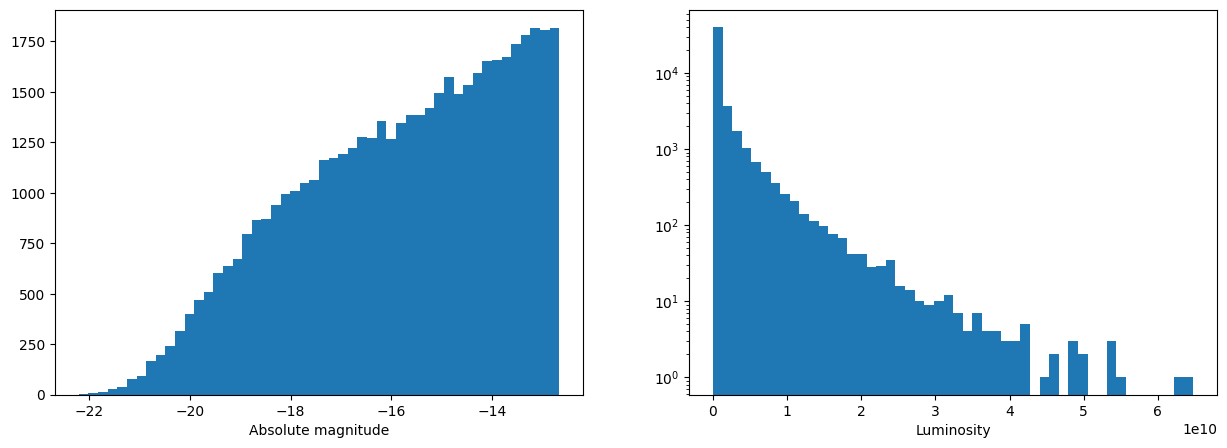

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
get_hist(data["M"], xlabel='Absolute magnitude', bins=50, figax=(fig, ax[0]))
get_hist(data["L"], xlabel='Luminosity', bins=50, figax=(fig, ax[1]), log=True);

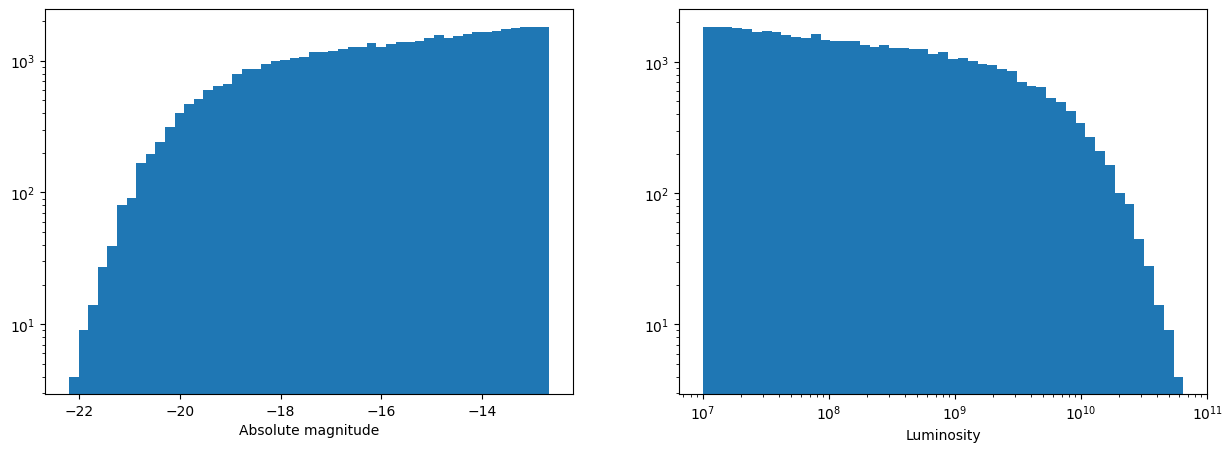

In [7]:
binsL = np.logspace(np.log10(np.min(data["L"])), np.log10(np.max(data["L"])), 50)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
get_hist(data["M"], xlabel='Absolute magnitude', bins=50, figax=(fig, ax[0]))
get_hist(data["L"], xlabel='Luminosity', bins=binsL, figax=(fig, ax[1]))
ax[0].set_yscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log');

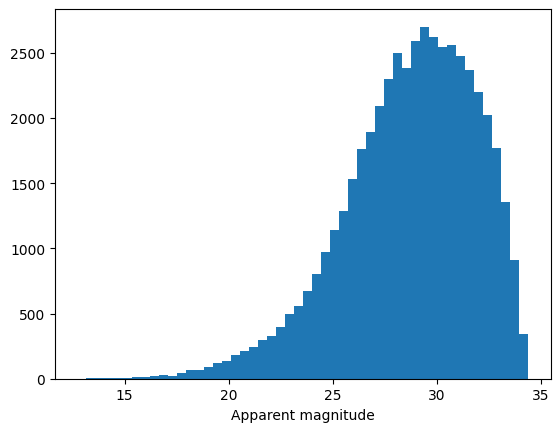

In [8]:
get_hist(data["m"], xlabel='Apparent magnitude', bins=50);

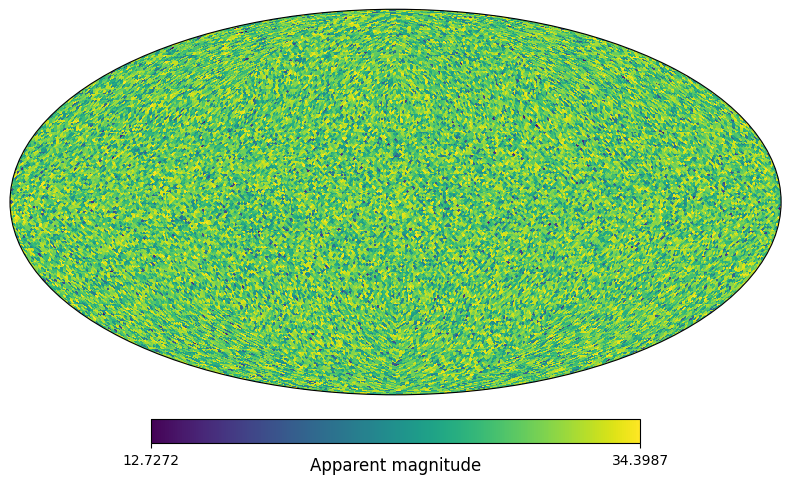

In [9]:
hp.projview(data["m"], unit="Apparent magnitude");

## $m_5$ magnitude

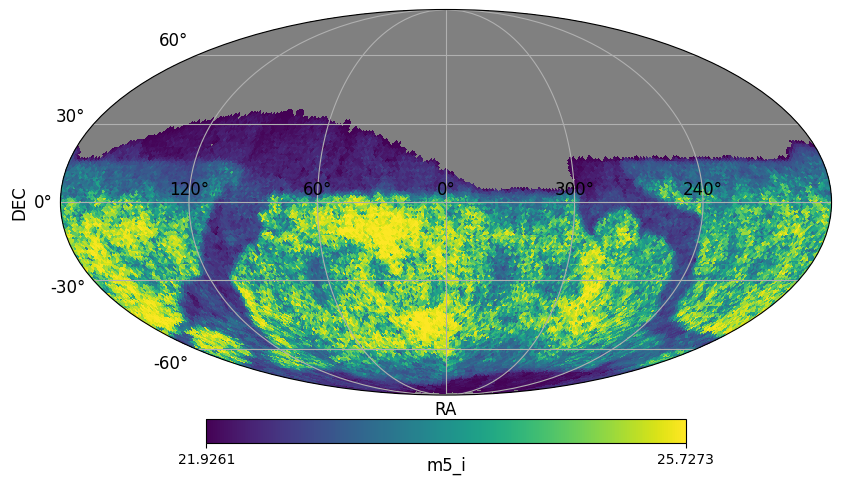

In [10]:
DIR = '../data/'
FILE = DIR + "baseline_v5.0.0_10yrs_summary.hdf5"
dm = DepthMapper.read_hdf(FILE)
dm.select_year(1)
dm.select_band('i')
dm.set_mask()
dm.plot()

## N sources sampling

In [11]:
NSource_px_th = int(1e6)
dataN = generate_lumMag(NSource_px_th, to_table=True)
dataN

Number of rejects = 295829


z,dL,L,M,m
,Mpc,solLum,,
float64,float64,float64,float64,float64
0.5897508740847393,3571.790962685695,90790934.52668734,-15.06510621597265,27.699323954470756
0.019013011757955955,85.84792206184076,4035726568.121938,-19.184804334708424,15.483844603195712
0.3058617552471231,1644.728020258952,44362509.72244179,-14.287540268837974,26.79293018767843
0.21546797534699924,1104.5857804913878,145698479.60314792,-15.578637549579257,24.63735969132891
0.5517315698485962,3296.149478525983,2037546844.984246,-18.442769005842052,24.14726548656942
1.7279120299239836,13337.727655108582,103247602.57470764,-15.204699940151277,30.420709286121436
0.7086455116227874,4463.336366056787,1019969890.2616922,-17.691468378703306,25.55682970821916
1.249634361439227,8956.715171630018,18446974.78768508,-13.334812885487006,31.42593093269025


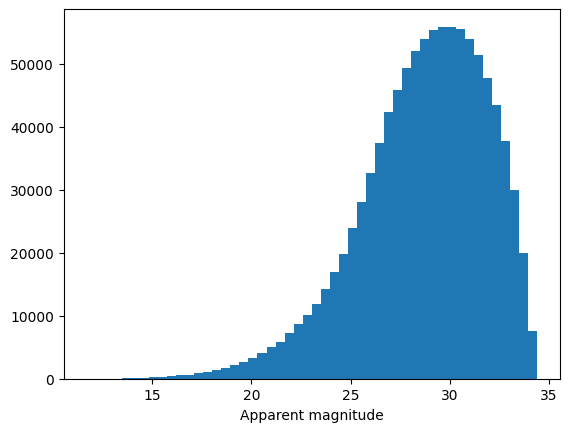

In [12]:
get_hist(dataN["m"], xlabel='Apparent magnitude', bins=50);

In [13]:
def get_cut_m52nSources(m, m5):
    m, m5 = np.array(m), np.array(m5)
    if (m.ndim == 1) & (m5.ndim ==1):  m, m5 = m.reshape(1, -1), m5.reshape(-1, 1) #to broadcast m and m5
    mask = m <= m5
    return np.count_nonzero(mask, axis=1)

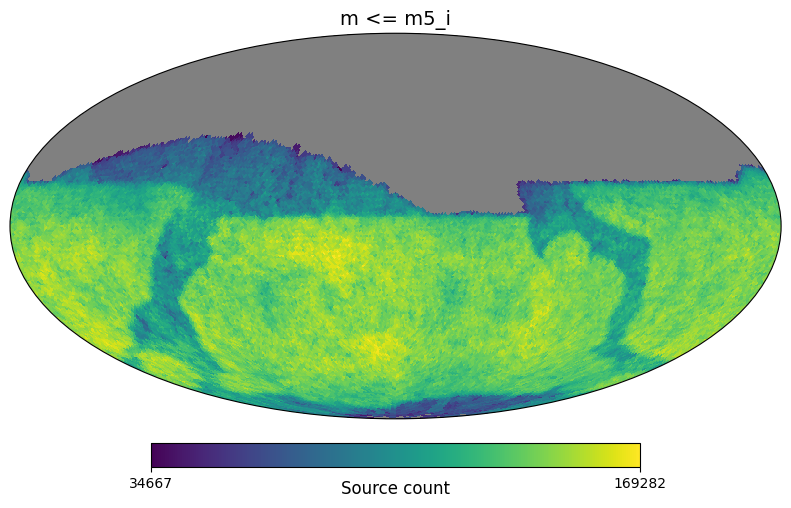

In [14]:
def get_cut_m52NSources_dask(m, m5, chunk_size=10_000):
    m = da.from_array(np.array(m), chunks=chunk_size)
    m5 = da.from_array(np.array(m5), chunks=chunk_size)

    if (m.ndim == 1) and (m5.ndim == 1):
        m = m.reshape(1, -1)
        m5 = m5.reshape(-1, 1)

    mask = m <= m5
    result_dask = mask.sum(axis=1)
    return result_dask.compute()

NSource_px = get_cut_m52NSources_dask(dataN["m"], dm.m5i.copy(), chunk_size=1e4)
NSource_px = hp.ma(NSource_px, badval=0)
hp.projview(NSource_px, nest=True, unit="Source count", title= "m <= m5_i");

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.533e+08 (χ²/ndof = 3118.3)│              Nfcn = 513              │
│ EDM = 2.34e-05 (Goal: 0.0002)    │            time = 5.5 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │115.8243e3 │ 0.0023e3  │ -0.0023e3  │  0.0023e3  │    0    │         │       │
│ 1 │ A    │ 231.38e-3 │  0.04e-3  │  -0.04e-3  │  0.04e-3   │    0    │    1    │       │
│ 2 │ ra   │  257.766  │   0.035   │   -0.035   │   0.035    │    0    │   360   │       │
│ 3 │ dec  │  -78.288  │   0.007   │   -0.007   │   0.007    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -2.3    │    2.3    │ -0.04e-3  │  0.04e-3  │  -0.035   │   0.035   │  -0.007   │   0.007   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────┐
│     │           M           A          ra         dec │
├─────┼─────────────────────────────────────────────────┤
│   M │        5.45 -57.7910e-6      0.0075     5.77e-3 │
│   A │ -57.7910e-6    1.62e-09   -108.5e-9    -98.0e-9 │
│  ra │      0.0075   -108.5e-9     0.00122     0.01e-3 │
│ dec │     5.77e-3    -98.0e-9     0.01e-3     5.2e-05 │
└─────┴─────────────────────────────────────────────────┘

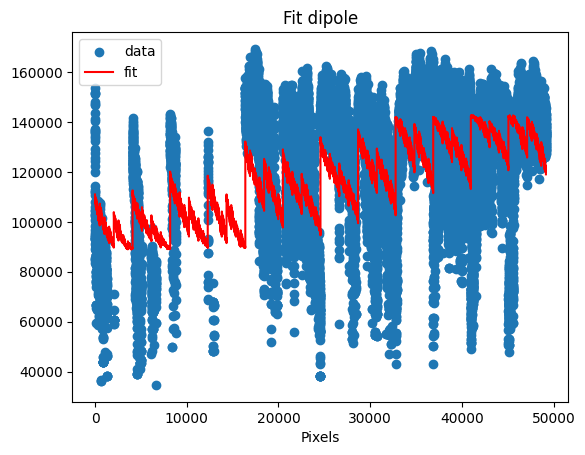

In [15]:
map = NSource_px 
model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=True, cut_masked=True, frame='icrs', contrast=False)
init =  (1000, 1, 100, 40)
names = ("M", "A", "ra", "dec")
m = fit_dipole_err(model, map, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]))
m

/home/victoria/Travaux_Jupyter_Ububtu/M2Stage_JohannGit/M2_Stage_Code/Simulation/simulMap.py:212: RuntimeWarning: invalid value encountered in sqrt
  if weights is not None: y_err = y_err/np.sqrt(weights)


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 8.865e+07 (χ²/ndof = 1803.8)│              Nfcn = 524              │
│ EDM = 0.000197 (Goal: 0.0002)    │            time = 5.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │121.3888e3 │ 0.0028e3  │ -0.0028e3  │  0.0028e3  │    0    │         │       │
│ 1 │ A    │ 192.17e-3 │  0.05e-3  │  -0.05e-3  │  0.05e-3   │    0    │    1    │       │
│ 2 │ ra   │  264.60   │   0.05    │   -0.05    │    0.05    │    0    │   360   │       │
│ 3 │ dec  │  -79.690  │   0.009   │   -0.009   │   0.009    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -2.8    │    2.8    │ -0.05e-3  │  0.05e-3  │   -0.05   │   0.05    │  -0.009   │   0.009   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────┐
│     │           M           A          ra         dec │
├─────┼─────────────────────────────────────────────────┤
│   M │        8.03 -89.9461e-6      0.0117     8.27e-3 │
│   A │ -89.9461e-6    2.23e-09   -165.4e-9   -131.9e-9 │
│  ra │      0.0117   -165.4e-9     0.00259     0.02e-3 │
│ dec │     8.27e-3   -131.9e-9     0.02e-3    8.75e-05 │
└─────┴─────────────────────────────────────────────────┘

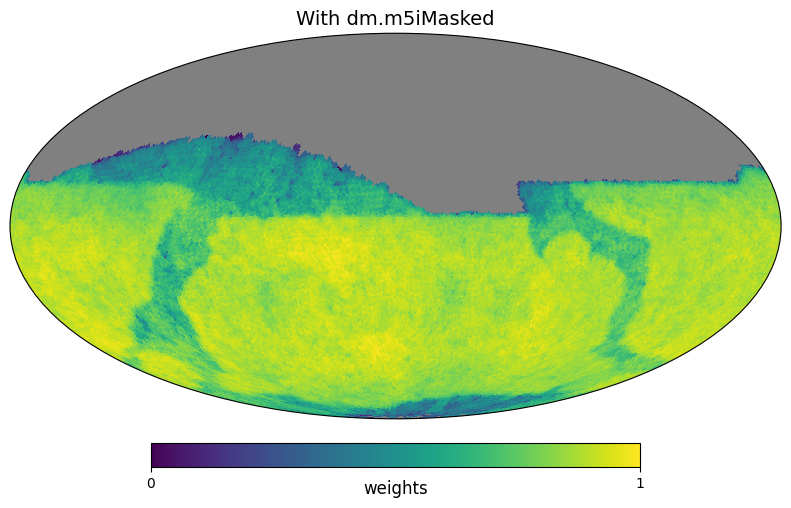

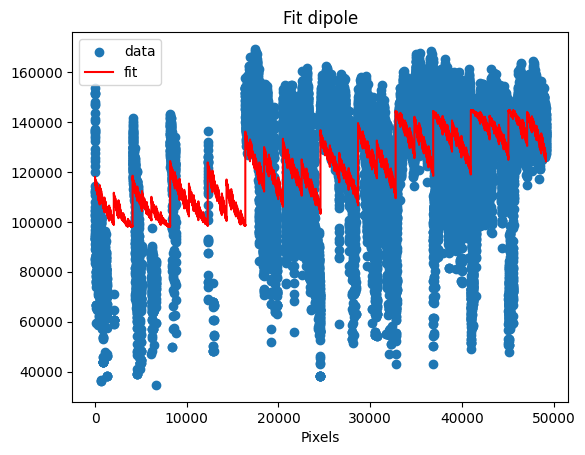

In [16]:
def renormalize(v):
    var=v.copy()
    var_min = var.min()
    var_max = var.max()
    return (var - var_min) / (var_max - var_min)


map = NSource_px
weights1 = renormalize(dm.m5iMasked)
hp.projview(weights1, nest=True, unit="weights", title= "With dm.m5iMasked");

model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=True, cut_masked=True, frame='icrs', contrast=False)
init =  (1000, 1, 100, 40)
names = ("M", "A", "ra", "dec")
m = fit_dipole_err(model, map, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]), weights=weights1)
m

Unable to use minos()


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.471e+08 (χ²/ndof = 2993.4)│              Nfcn = 262              │
│ EDM = 4.48e-09 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│           Hesse FAILED           │       Covariance NOT pos. def.       │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │  1.156e5  │  0.000e5  │            │            │    0    │         │       │
│ 1 │ A    │ 2.3791e-1 │ 0.0000e-1 │            │            │    0    │    1    │       │
│ 2 │ ra   │ 2.2542e1  │ 0.0000e1  │            │            │    0    │   360   │       │
│ 3 │ dec  │   -9e1    │    0e1    │            │            │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘

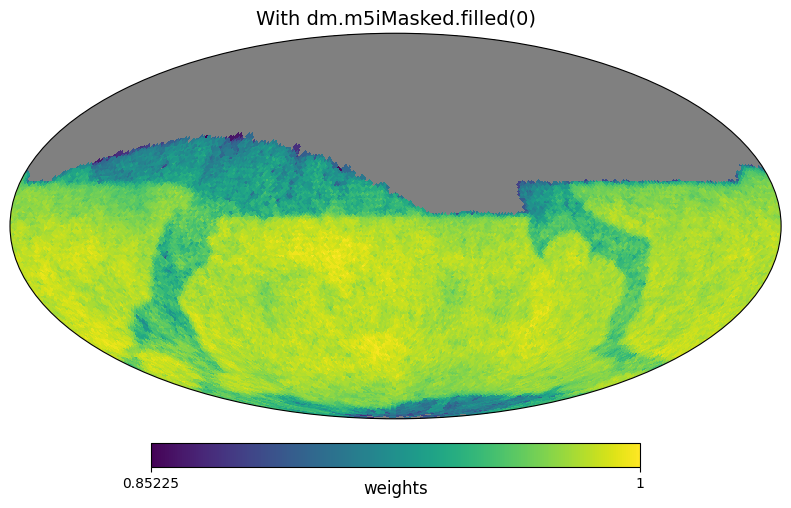

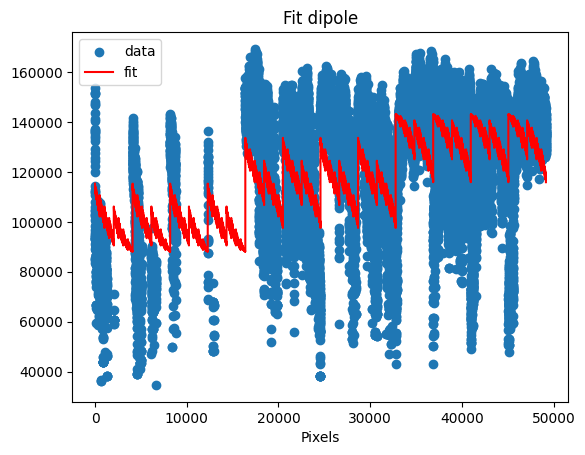

In [17]:
map = NSource_px
weights2 = renormalize(dm.m5iMasked.filled(0))
weights2 = hp.ma(weights2)
weights2.mask = dm.m5iMasked.mask
hp.projview(weights2, nest=True, unit="weights", title= "With dm.m5iMasked.filled(0)");

model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=True, cut_masked=True, frame='icrs', contrast=False)
init =  (1000, 1, 100, 40)
names = ("M", "A", "ra", "dec")
m = fit_dipole_err(model, map, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]), weights=weights2)
m

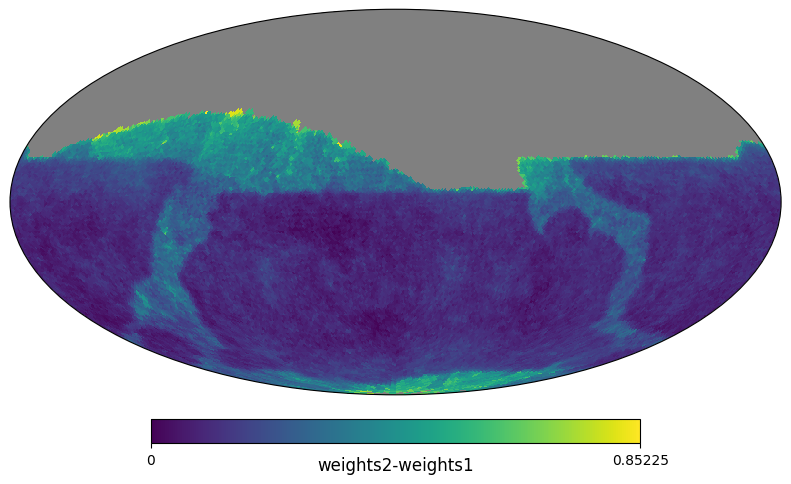

In [18]:
hp.projview(weights2-weights1, nest=True, unit="weights2-weights1", title= "");